## Usfull libraries:


In [ ]:
import camb
from camb import model, initialpower
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord
from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.integrate import simpson
from CosmoFunc import *
import time

## cosmological parameters:

In [463]:
OmegaM= 0.3151
OmegaLambda = 1.0-OmegaM
Omegarad = 10**(-5)
H0 = 67.27
c = 299792.458 # speed of light in km/s
wo = -1 # for lambdaCDM
wa = 0 # for lambdaCDM

## 1.get the linear PS from CAMB:

sigma8_fid =  0.811750044674705


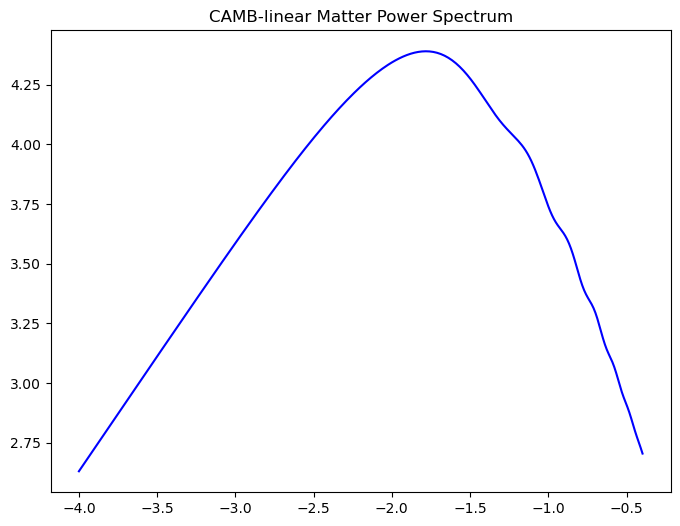

In [464]:
pars = camb.CAMBparams()
pars.set_cosmology(H0,ombh2=0.022, omch2=0.1198)
pars.set_dark_energy() #re-set defaults
pars.InitPower.set_params(As=2.114940245149156e-09,ns=0.9645)
pars.set_matter_power(redshifts=[0.], kmax=0.4)
pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)
khs, z, pks = results.get_matter_power_spectrum(minkh=1e-4, maxkh=0.4, npoints = 300) 
Sig8_fid = results.get_sigma8()[0]
Pk_linear=pks[0,:]
k_linear=khs
print( 'sigma8_fid = ',Sig8_fid)

plt.figure(4,figsize=(8,6))
plt.plot(np.log10(k_linear),np.log10(Pk_linear),color='b')
plt.title('CAMB-linear Matter Power Spectrum')
plt.show()

outfile = open('C:/Users/lucil/Documents/Stage M2/codes/codes_bulk_flow/results/power_spectrum_camb.dat', 'w')
outfile.write(" %18d\n"% (len(k_linear)))
for i in range(len(k_linear)):  
    outfile.write("%12.6lf  %12.6lf  \n"% (k_linear[i],Pk_linear[i]))
outfile.close()

## 2. get the coordinates of r from the (Ra,dec) coordinates from data:

In [491]:
# extract the Ra,Dec and z from the data file:
data_PC = 'C:/Users/lucil/Documents/Stage M2/data_DESI/PV_clustering_data_v5_v13.fits'
hdul = fits.open('C:/Users/lucil/Documents/Stage M2/data_DESI/PV_clustering_data_v5_v13.fits')
print(hdul[1].columns.names)  # the names of the columns in the data file

with fits.open(data_PC) as hfile:
    infile = hfile[1].data


ra    = infile['RA']
dec   = infile['DEC']
z    = infile['Z']
z_err = infile['ZCMB'] # the error on the redshift ?
logdist  = infile['LOGDIST']
err_logdist = infile['LOGDIST_ERR']
weights = infile['WEIGHT'] # But we have one weight for one galaxy and for one component Bx,By;Bz,Qxx,Qxy,... 
pv = infile['PV'] 
pv_err = infile['PV_ERR'] 

n_galaxies = len(z)
print('number of galaxies in the data file :', n_galaxies)


['TARGETID', 'SGA_ID', 'FP_FLAG', 'RA', 'DEC', 'Z', 'ZCMB', 'WEIGHT', 'NPV', 'NDENS', 'MU', 'MU_ERR', 'LOGDIST', 'LOGDIST_ERR', 'PV', 'PV_ERR']
number of galaxies in the data file : 80628


In [482]:
# Now we want to extract the comoving distances of the galaxie assuming a model from the redshift:
d_comoving = []
d_trasverse = []
d_luminosity = []
d_angular = []

for i in range(n_galaxies):
    d_angular.append(DistDa(z[i], OmegaM, OmegaLambda, Omegarad, H0, wo, wa, ap=1))
    d_luminosity.append( DistDl(z[i], OmegaM, OmegaLambda, Omegarad, H0, wo, wa, ap=1)) # in Mpc
    d_comoving.append(DistDc(z[i], OmegaM, OmegaLambda, Omegarad, H0, wo, wa, ap=1)) # in Mpc ap does not matter for the distance
    d_trasverse.append(DistDm(z[i], OmegaM, OmegaLambda, Omegarad, H0, wo, wa, ap=1)) 

In [483]:
print('The comoving distance of the first galaxy :', d_comoving[0], 'Mpc')
print('The luminosity distance of the first galaxy :', d_luminosity[0], 'Mpc')
print('The trasverse distance of the first galaxy :', d_trasverse[0], 'Mpc')
print('The angular distance of the first galaxy :', d_angular[0], 'Mpc')

The comoving distance of the first galaxy : 3377.4830513664233 Mpc
The luminosity distance of the first galaxy : 6714.219893492139 Mpc
The trasverse distance of the first galaxy : 3377.479818188465 Mpc
The angular distance of the first galaxy : 1698.9866437539758 Mpc


In [484]:
# Now that we have the comobile distance we can reconstruct the 3D r vector using the Ra and Dec: r_n = d_comoving[n] * r^n
# We convert the Ra and Dec in cartesian coordinates :

x=  np.cos(dec) * np.cos(ra)
y=  np.cos(dec) * np.sin(ra)
z =  np.sin(dec)

# We stack the x,y,z in a single array:
r_hat = np.vstack((x, y, z)).T
d_comoving = np.array(d_comoving) # the comoving distance in Mpc must be an array to be able to convert it in a [N,1] array to multiply it with r_hat [N,3]
r = r_hat * d_comoving[:, None]

# We print the first comoving distance, the first r_hat and the first r to check that everything is correct:
print('d_comoving of the first galaxy = ',d_comoving[0],'Mpc')
print('r_hat of the first galaxy = ',r_hat[0])
print('r of the first galaxy = ',r[0],'Mpc')

d_comoving of the first galaxy =  3377.4830513664233 Mpc
r_hat of the first galaxy =  [-0.03673133  0.15043157  0.98793783]
r of the first galaxy =  [-124.05944844  508.08008137 3336.74326948] Mpc


## 3. get fnm function :

In [485]:
def f_nm(k,n,m,d_comoving):

    # get the 3D vector r from r_hat and d_comoving:
    d_comoving = np.array(d_comoving)
    r_hat_n = r_hat[n]
    r_hat_m = r_hat[m]
    rn = r_hat_n * d_comoving[n, None]
    rm = r_hat_n * d_comoving[m, None]

    d_nm = np.linalg.norm(rn - rm)
    #print('d_nm = ',d_nm,'Mpc')

    scal = r_hat_n @ r_hat_m
    alfa_nm = np.arccos(scal)
    #print('alfa_nm = ',alfa_nm,'rad')
      
    return 1/3*(special.spherical_jn(0,k*d_nm) - 
                2*special.spherical_jn(2,k*d_nm))* np.dot(r_hat_n, r_hat_m)*special.spherical_jn(2,k*d_nm)* np.dot(rn,rm) *(np.sin(alfa_nm)**2) / d_nm**2


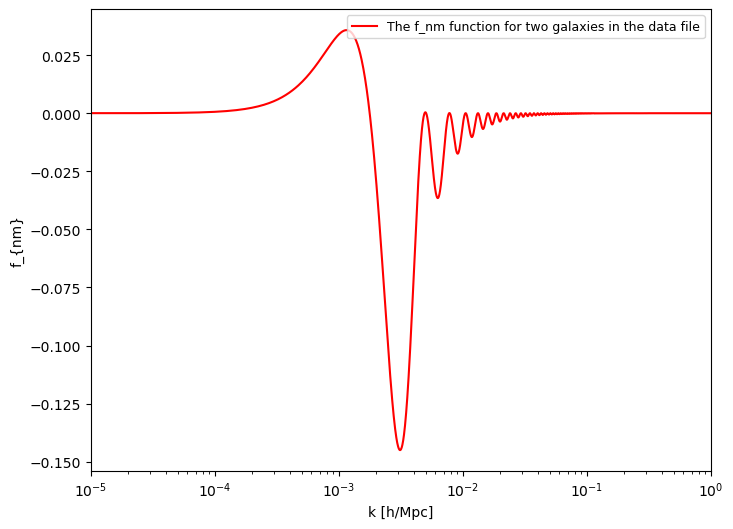

In [486]:
# exemple with the first and the 50th galaxy in the data file:

plt.figure(4,figsize=(8,6))
k_max = 1
k_linear = np.linspace(0,k_max,80628)
plt.xscale('log')
plt.plot(k_linear,f_nm(k_linear,0,41,d_comoving),color='r',label='The f_nm function for two galaxies in the data file')
plt.xlim(1e-5,k_max)
plt.legend(fontsize=9, loc='upper right')
plt.xlabel('k [h/Mpc]')
plt.ylabel('f_{nm}')

plt.show()

## 4.get the window function:

In [490]:
# test print of the values we extracted from the data file to see the order of magnitude :
print('the redshift of the first galaxy :', z[0])
print('the redshift error of the first galaxy :', z_err[0])
print('the logdistance of the first galaxy :', logdist[0],'Mpc') 
print('the error on the logdistance of the first galaxy :', err_logdist[0],'Mpc')

the redshift of the first galaxy : 0.9879378278841524
the redshift error of the first galaxy : 0.04508261475414366
the logdistance of the first galaxy : 0.02936390515362472 Mpc
the error on the logdistance of the first galaxy : 0.11260253819160884 Mpc


In [492]:
# calculate the error on the peculiar velocity using the error on the logdistance and the redshift of the first galaxy:

alpha_n = np.log(10) * c * z * err_logdist / (1+z) # error on the peculiar velocity in km/s
alpha_star = 300 # in km/s is a estimation of the typical intrinsic dispersion of the peculiar velocity of the galaxies


print('the peculiar velocity error of the galaxies :', pv,'km/s') # the values are between 10 and 20 000 km/s
print('the error on the peculiar velocity of the first galaxy calculated :', alpha_n, 'km/s')
print('the error on the peculiar velocity of the first galaxy from data file:', pv_err,'km/s')

error_percent_data = 100 * np.abs(pv_err / pv)
error_percent_calc = 100 * np.abs(alpha_n / pv)
error_percent_distance = 100 * np.log(10) * err_logdist

print('the percentage error on the peculiar velocity of the first galaxy data :', error_percent_data[0], '%')
print('the percentage error on the peculiar velocity of the first galaxy calculated :', error_percent_calc[0], '%') 
print('the percentage error on the logdistance of the first galaxy :', error_percent_distance[0], '%')

the peculiar velocity error of the galaxies : [   924.38684668   2930.69452993   1627.9136967  ... -16415.85521313
     98.53494757    909.82932889] km/s
the error on the peculiar velocity of the first galaxy calculated : [3276.06288022 6017.89772905 3102.01631781 ... 4921.79859828 5256.36862034
 1506.54189494] km/s
the error on the peculiar velocity of the first galaxy from data file: [3544.77051545 6812.87420534 3313.78541142 ... 5386.46190706 5753.50858296
 1465.30173884] km/s
the percentage error on the peculiar velocity of the first galaxy data : 383.4726260097221 %
the percentage error on the peculiar velocity of the first galaxy calculated : 354.4038831782764 %
the percentage error on the logdistance of the first galaxy : 25.927692587329123 %


In [493]:
# Lets calculate the weights with the formula from the paper:

# calculating the g function for each galaxy:
x = r_hat[:, 0]
y = r_hat[:, 1]
z = r_hat[:, 2]
g = np.column_stack([x,y,z, d_comoving*x**2,d_comoving * y**2,d_comoving * z**2,2*d_comoving * x*y,2*d_comoving * x*z,2*d_comoving * y*z]) 
print('g of the first galaxy :', g[0]) # the shape of g is (N, 9) where N is the number of galaxies in the data file and 9 is the number of components of the g function


# calculating the A matrix:
alpha_tot2 = alpha_n**2 + alpha_star**2  # (N,)
A = g.T @ (g / alpha_tot2[:, None])
#print('A matrix :', A) # the shape of A is (9, 9)


# calculating the weights:
A_inv = np.linalg.inv(A)
w = 1 / (alpha_n**2 + alpha_star**2)
weights_calc = A_inv @ (g * w[:, None]).T
print("weights shape:", weights_calc.shape) # is (9, N)
print('the weights of the data file of the first galaxie calculated with the formula from the paper :', weights_calc[:,0])

g of the first galaxy : [-3.67313312e-02  1.50431571e-01  9.87937828e-01  4.55686868e+00
  7.64312848e+01  3.29649490e+03 -3.73249154e+01 -2.45126044e+02
  1.00390306e+03]
weights shape: (9, 80628)
the weights of the data file of the first galaxie calculated with the formula from the paper : [ 3.53279034e-06 -1.22402601e-05  2.85971169e-04 -7.83709462e-08
 -7.36536834e-08 -5.12856461e-08 -7.67674806e-10 -2.87940591e-09
  1.10186796e-08]


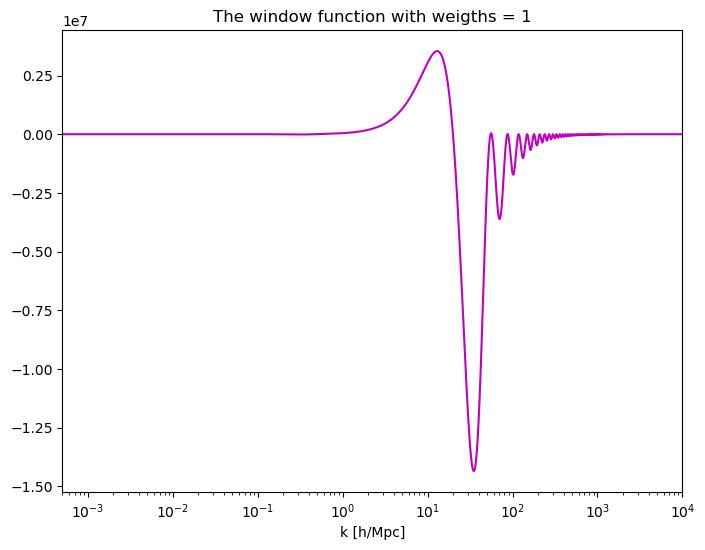

In [511]:
# test of the window function if all weights = 1:

def window_function_1(k,N):
    
    w = 0
    for n in range (0,N):
        for m in range (0,N):
            if n != m: 
                w += f_nm(k,n,m,d_comoving)

    return w
k_max = 10000
k = np.linspace(0.00001,k_max,80628)
plt.figure(4,figsize=(8,6))
plt.xscale('log')
plt.plot(k,window_function_1(k,N=100),color='m')
plt.xlim(5*10**-4,k_max)
plt.title('The window function with weigths = 1')
plt.xlabel('k [h/Mpc]')
plt.show()

In [512]:
# test of the window function with the weights calculated with the formula from the paper:

def window_function_2(k, p, q, N):

    W = 0

    for n in range(N):
        for m in range(N):
            if n != m: 

                W += ( weights_calc[p, n] * weights_calc[q, m] * f_nm(k,n,m, d_comoving))

    return W


##  5. plot of the window function :

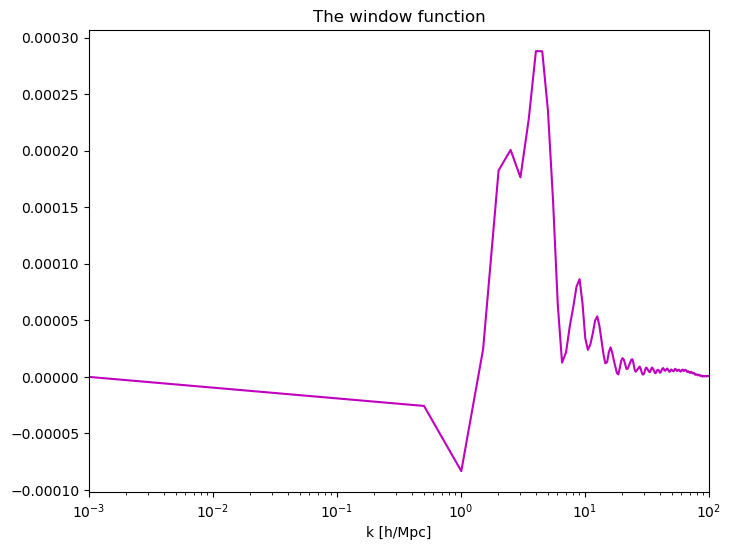

In [513]:
N = 200
k_max = 100
k = np.linspace(0.001,k_max,N)
plt.figure(4,figsize=(8,6))
plt.xscale('log')
plt.plot(k,window_function_2(k,0,1,N),color='m')
plt.xlim(1e-3,k_max)
plt.title('The window function')
plt.xlabel('k [h/Mpc]')
plt.show()

In [515]:
# integral of the window function for p=0 and q=1:

def Window(k):

    return window_function_2(k,p=0,q=1,N=100)

result, error = quad(Window, 0.001, 100)

print("Integral =", result)
print("Error estimate =", error)

KeyboardInterrupt: 

## R_pq the CRMS (cosmic root mean square) variation : 

In [ ]:
# integral with simpson method for p=0 and q=1:

W = window_function_2(k,0,1,N=100)
R = W * Pk_linear * OmegaM * H0**2 / (2*np.pi**2)

k = np.linspace(0.001,100,100)
start = time.time()
result = simpson(R, k)
end = time.time()

print("Integral with simpson =", result)
print("Time taken:", end - start, "seconds")

TypeError: f_nm() missing 1 required positional argument: 'd_comoving'

In [ ]:
# intergrate with the quad method but it is a little more slow :

Pk_interp = interp1d(khs, Pk_linear, kind='linear', bounds_error=False, fill_value=0)

def R_scalar(khs):
    return window_function_2(khs,N=20) * Pk_interp(khs) * OmegaM * H0**2 / (2*np.pi**2)

result, error = quad(R_scalar, 0.001, 0.4 )

print("Integral =", result)
print("Error estimate =", error)

Integral = 1823.1742977742267
Error estimate = 0.08087508875746607


C:\Users\lucil\AppData\Local\Temp\ipykernel_2612\1659781856.py:8: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = quad(R_scalar, 0.001, 0.4 )
